### **CURVA DE PHILIPS**
Representa a relação entre duas das principais variáveis de economia: **inflação** e o **desemprego**</br></br>
Na formulação classica, demonstrava uma relação inversa entre as duas variáveis.
- Quando o desemprego está alto, a inflação tende a ser baixa
- Quando o desemprego está baixo, a inflação tende a subbir </br></br>
Lógica: Quando a economia está crescento, o desemprego dimnui, fazendo com que as empresas tenham que disputar mão de obra, o que acaba aumentando os salários. Como o custo de produção mias alto, as empresas acabam repassando este custo para o consumidor, o que acaba gerando inflação;

### **EVOLUÇÃO DA CURVA DE PHILIPS DE CURTO E DE LONGO PRAZO**
Com o tempo e com os choques economicos (como a crise do petroleo que gerou inflação alta junto com desemprego alto, fenomeno conhecido como estagflação), a teoria original precisou ser redefiida.
1) **No ccurto prazo** a relação inversa ainda tende a funcionar. Governos podem, temporariameente estimular a economia para reduzir o desemprego aceitando um pouco mais de inflação em troca. 
2) **No Longo Prazo** No longo prazo a ccurva torna-se **vertical** na altura da chamada **Taxa Natural de Desemprego** (ou NAIRU- Taxa de desemprego que não acelera a inflação). No logo prazo, tentar manter o desmeprego artificialmente abaixo dessa taxa natural não reduz o desemprego permanente, apenas gera uma expiral inflacinária descontrolada.

### **SERVE PARA QUE?**
**1) Auxílio na Poliica Monetária**: Banco centrais utilizam versões modernas da curva de Philipsnos seus modelos de projeção. Ela serve para estimar como a temperatura da economia e o mercado de trabalho (vagas, salários e desemprego) devem pressionar a inflação futtura, ajudando a decidir o rumo da taxa bascia de juros. </br></br>
**2) Diagnostrico de Conjuntura**: Permite aos analistas entenderem em que fase do ciclo economico a economia se encontra - se há excesso de capacidade ociosa (desemprego alto e inflação baixa) ou se a economia está sobreaquecida (desemprego muito baixo, gerando pressões de preços)

In [2]:
import pandas as pd 
import numpy as np

import seaborn as sns 
import matplotlib.pyplot as plt

from bcb import sgs

import statsmodels.formula.api as smf

sns.set()

In [3]:
DATA_CONSULTA = '2000-01-01'

In [4]:
dados_bcb = sgs.get({'Desemprego': 24369, 'Inflacao_12m': 13522}, start=DATA_CONSULTA)

dados_bcb = dados_bcb.dropna()

In [5]:
dados_bcb.index.min()

Timestamp('2012-03-01 00:00:00')

No Gráfico abaixo podemos ver o comportamento histórico tando do desemprego, quando da inflação ao longo da série histórica que baixamos do site do Banco Central do Brasil.

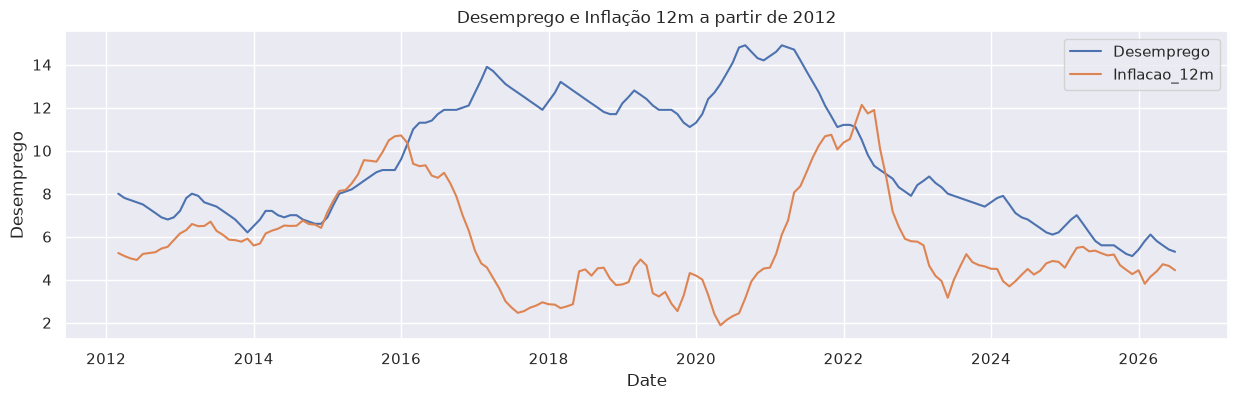

In [6]:
DATA_INICIAL = '2012-01-01'
plt.figure(figsize=(15,4))
plt.title(f'Desemprego e Inflação 12m a partir de {DATA_INICIAL.split("-")[0]}')
sns.lineplot(data=dados_bcb.query(f"Date > '{DATA_INICIAL}'"), x=dados_bcb.query(f"Date > '{DATA_INICIAL}'").index, y='Desemprego', label='Desemprego')
sns.lineplot(data=dados_bcb.query(f"Date > '{DATA_INICIAL}'"), x=dados_bcb.query(f"Date > '{DATA_INICIAL}'").index, y='Inflacao_12m', label='Inflacao_12m')
plt.show()

#### **VERIFICANDO A RELAÇÃO ENTRE O DESEMPREGO E A INFLAÇÃO**

Pode-se observar que existem dois comportamentos bastante distintos.</br></br>
Quando temos o desemprego abaixo de 10% aparentemente temos umarelação fortemente positiva com a inflação</br></br>
Já quando temos um desemprego acima de 10% a correlação passa a ser negativa

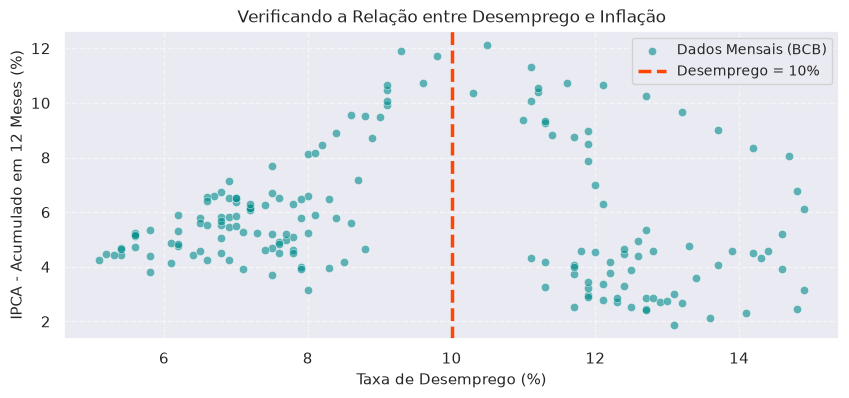

In [12]:
plt.figure(figsize=(10, 4))
plt.title('Verificando a Relação entre Desemprego e Inflação')

sns.scatterplot(data=dados_bcb, x='Desemprego', y='Inflacao_12m', 
                color='darkcyan', alpha=0.6, label='Dados Mensais (BCB)'
                )

plt.axvline(10, ls='--', color='orangered', linewidth=2.5, label='Desemprego = 10%')
plt.xlabel('Taxa de Desemprego (%)', fontsize=11)
plt.ylabel('IPCA - Acumulado em 12 Meses (%)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##### **PRIMEIRO MODELO**

Abaixo, temos nosso primeiro modelo de Curva de Philips sendo executado. </br></br>
Observa-se que o desemprego possui um coeficiente negativo conforme a teoria da Curva de Phillips, porem, a variável não possui significancia estatistica, o que pode indicar ausencia de outras variáveis explicativas.

In [8]:
formula = 'Inflacao_12m ~ Desemprego'
modelo = smf.ols(formula=formula, data=dados_bcb).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           Inflacao_12m   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9834
Date:                Sat, 26 Sep 2026   Prob (F-statistic):              0.323
Time:                        13:18:15   Log-Likelihood:                -394.28
No. Observations:                 173   AIC:                             792.6
Df Residuals:                     171   BIC:                             798.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.3585      0.636     10.000      0.0

#### **VERIFICANDO A CURVA DE PHILIPS COM DESEMPREGO ENTRE 0 A 10%**

Com base na regressão abaixo, podemos identificar que o desemprego tem uma relação positiva com a inflação, o que do ponto de vista prático vai contra o conceito da curva de Philips. </br></br>
Isso pode indicar que temos mais variáveis explicativas que não estão fazendo parte do modelo confirme vimos no modelo anterior. Porem, neste modelo, o coeficiente da variavel desemprego passa a ser significativo do ponto de vista estatistico.

In [78]:
df_acima_10 = dados_bcb[dados_bcb['Desemprego'].between(0, 10)]

In [82]:
formula_1 = 'Inflacao_12m ~ Desemprego'
model_1 = smf.ols(formula=formula_1, data=df_acima_10).fit()
print(model_1.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.0528      0.998     -2.056      0.042      -4.035      -0.071
Desemprego     1.1058      0.136      8.157      0.000       0.837       1.375


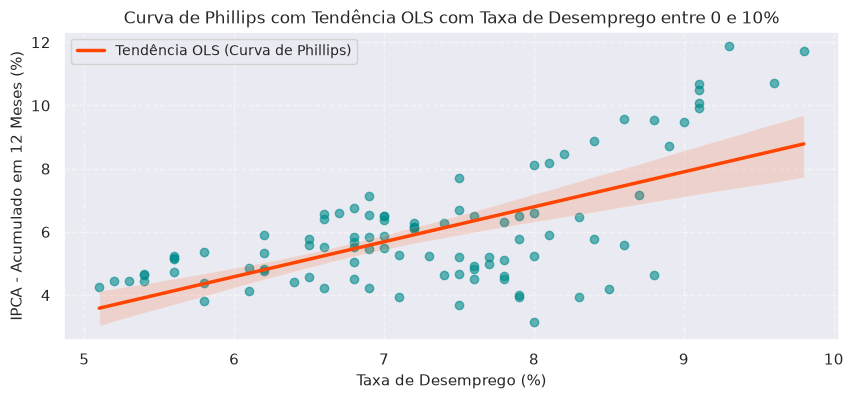

In [ ]:


plt.figure(figsize=(10, 4))
plt.title('Curva de Phillips com Tendência OLS com Taxa de Desemprego entre 0 e 10%')

sns.regplot(data=df_acima_10, x='Desemprego', y='Inflacao_12m',
            scatter_kws={
                'alpha': 0.6,
                'color': 'darkcyan',
                'label': 'Dados Mensais (BCB)',
            },
            line_kws={
                'color': 'orangered',
                'linewidth': 2.5,
                'label': 'Tendência OLS (Curva de Phillips)',
            },
           )
plt.xlabel('Taxa de Desemprego (%)', fontsize=11)
plt.ylabel('IPCA - Acumulado em 12 Meses (%)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **VERIFICANDO A CURVA DE PHILIPS COM DESEMPREGO ACIMA DE 10%**

Novamente, a variavel Desemprego passa a ter significancia estatistica, o que me leva a crer que adicionando uma variavel dummy, o ajuste do modelo tenda a melhorar. 

In [83]:
df_acima_10 = dados_bcb[dados_bcb['Desemprego']>10]

In [84]:
formula_2 = 'Inflacao_12m ~ Desemprego'
model_2 = smf.ols(formula=formula_2, data=df_acima_10).fit()
print(model_2.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     16.7302      3.479      4.809      0.000       9.797      23.663
Desemprego    -0.8999      0.276     -3.262      0.002      -1.450      -0.350


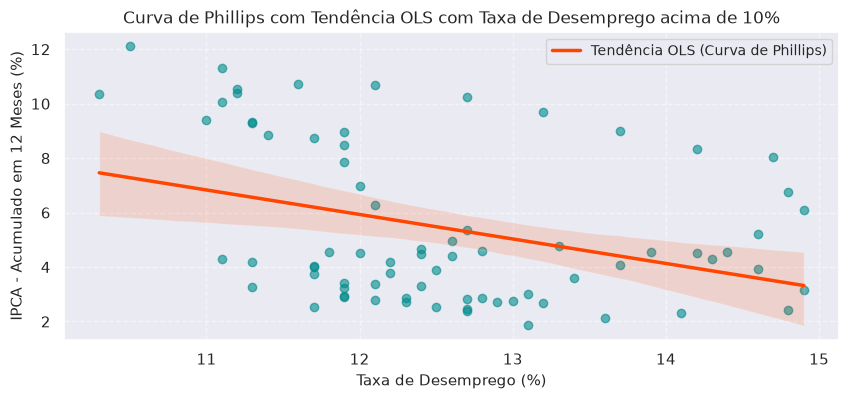

In [ ]:


plt.figure(figsize=(10, 4))
plt.title('Curva de Phillips com Tendência OLS com Taxa de Desemprego acima de 10%')

sns.regplot(data=df_acima_10, x='Desemprego', y='Inflacao_12m',
            scatter_kws={
                'alpha': 0.6,
                'color': 'darkcyan',
                'label': 'Dados Mensais (BCB)',
            },
            line_kws={
                'color': 'orangered',
                'linewidth': 2.5,
                'label': 'Tendência OLS (Curva de Phillips)',
            },
           )
plt.xlabel('Taxa de Desemprego (%)', fontsize=11)
plt.ylabel('IPCA - Acumulado em 12 Meses (%)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **TESTANDO CURVA DE PHILIPS COM VARIAVEL DUMMY**

Mesmo após adição da variável dummy o modelo ainda apresenta variaveis de entrada com coneficientes não significativos do ponto de vista estatistico. 

In [14]:
# CRIANDO VARIÁVEL INDICADORA PARA DESEMPREGO ACIMA DE 10%
dados_bcb_1 = (
    dados_bcb
        .assign(
            Desemprego_acima_10=lambda x: np.where(x['Desemprego'] > 10, 1, 0)
        )
)

In [15]:
formula_3 = 'Inflacao_12m ~ Desemprego_acima_10 + Desemprego'
model_3 = smf.ols(formula=formula_3, data=dados_bcb_1).fit()
print(model_3.summary().tables[1])

                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.6116      1.208      3.817      0.000       2.227       6.996
Desemprego_acima_10    -1.5797      0.931     -1.697      0.091      -3.417       0.258
Desemprego              0.1909      0.163      1.174      0.242      -0.130       0.512


#### **RODANDO O MODELO COM A INTERAÇÃO ENTRE  AS VARIÁVEIS**
Por fim, resolvo abordar o modelo de uma forma diferente: </br></br>
Como sabemos que o peso do desemprego sobre a inflação tem uma diferenã não linear, o modelo aditivo deixa de fazer sentido e temos que aplicar um modelo com Interação

In [101]:
formula_4 = 'Inflacao_12m ~ Desemprego_acima_10 * Desemprego'
model_4 = smf.ols(formula=formula_4, data=dados_bcb_1).fit()
print(model_4.summary().tables[1])

                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -2.0528      1.436     -1.430      0.155      -4.888       0.782
Desemprego_acima_10               18.7829      3.044      6.170      0.000      12.773      24.793
Desemprego                         1.1058      0.195      5.671      0.000       0.721       1.491
Desemprego_acima_10:Desemprego    -2.0057      0.289     -6.947      0.000      -2.576      -1.436
